# Python Miniproject :                           Customer Data Analysis 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import datetime as datetime

### Data Loading & Preview

In [2]:
df_master = pd.read_csv('C:\\Users\\ariji\Downloads\Python Miniproject Dataset\\Dataset\\Customer_Master_Data.csv')
df_txn = pd.read_csv("C:\\Users\\ariji\\Downloads\\Python Miniproject Dataset\\Dataset\\Customer_Transactions.csv")

In [3]:
df_master.head(10)


,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04
5,CUST10005,Fateh Sharaf,qkulkarni@gmail.com,Male,59,Jaipur,Single,3,2021-05-13
6,CUST10006,Khushi Wadhwa,craja@yahoo.com,Female,61,Hyderabad,Widowed,2,2021-11-12
7,CUST10007,Zeeshan Salvi,ira51@saini-kumar.com,Not Disclosed,32,Pune,Widowed,1,2021-08-10
8,CUST10008,Elakshi Trivedi,ayesha07@gmail.com,Female,32,Hyderabad,Widowed,4,2023-11-20
9,CUST10009,Neelofar Chada,abramsolanki@madan.com,Male,44,Jaipur,Single,0,2021-11-20


In [40]:
df_master.shape                            # Data Preview 
df_master.info

<bound method DataFrame.info of     CustomerID              Name                       Email  Gender  Age  \
0    CUST10000    Onkar Bhargava             pkeer@yahoo.com    Male   54   
1    CUST10001       Divit Kohli           mkalita@sarin.com  Female   48   
2    CUST10002        Kiara Behl        apteanay@hotmail.com    Male   75   
3    CUST10003    Vaibhav Sankar     bseshadri@choudhry.info    Male   62   
4    CUST10004      Shray D’Alia      bdhillon@toor-mall.com    Male   55   
..         ...               ...                         ...     ...  ...   
995  CUST10995       Mehul Chada    hridaanagate@hotmail.com    Male   70   
996  CUST10996       Arhaan Tara         qwali@mand-sood.com    Male   35   
997  CUST10997      Mahika Uppal            vdalal@yahoo.com  Female   70   
998  CUST10998  Bhamini Aggarwal  kartik15@bajaj-singhal.com    Male   37   
999  CUST10999       Alia Sekhon      urvichadha@hotmail.com    Male   67   

          City MaritalStatus  NumChildren  

In [41]:
df_txn

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,2023-07-31,2383.07
1,CUST10100,2024-03-10,497.54
2,CUST10031,2025-02-17,536.78
3,CUST10987,2023-07-17,314.89
4,CUST10831,2024-12-15,2543.19
...,...,...,...
23045,CUST10710,2024-03-11,931.09
23046,CUST10209,2024-06-19,2659.35
23047,CUST10570,2024-06-27,266.97
23048,CUST10075,2023-12-26,1671.73


In [42]:
df_txn.shape         # Data Preview 
df_txn.info

<bound method DataFrame.info of       CustomerID TransactionDate  TransactionAmount
0      CUST10771      2023-07-31            2383.07
1      CUST10100      2024-03-10             497.54
2      CUST10031      2025-02-17             536.78
3      CUST10987      2023-07-17             314.89
4      CUST10831      2024-12-15            2543.19
...          ...             ...                ...
23045  CUST10710      2024-03-11             931.09
23046  CUST10209      2024-06-19            2659.35
23047  CUST10570      2024-06-27             266.97
23048  CUST10075      2023-12-26            1671.73
23049  CUST10234      2024-07-07             981.32

[23050 rows x 3 columns]>

### Data Cleaning :

In [5]:
print(df_master.isnull().sum())     # checking nulls 
print(df_txn.isnull().sum())

CustomerID       0
Name             0
Email            0
Gender           0
Age              0
City             0
MaritalStatus    0
NumChildren      0
JoinDate         0
dtype: int64
CustomerID           0
TransactionDate      0
TransactionAmount    0
dtype: int64


In [6]:
# No null values are found

In [7]:
print(df_master.duplicated().sum())   # checking for dupes
print(df_txn.duplicated().sum())      

0
0


In [8]:
print(df_master['Gender'].unique())                   #checking unique values or typos 
print(df_master['City'].unique())
print(df_master['MaritalStatus'].unique())

['Male' 'Female' 'Not Disclosed']
['Delhi' 'Kolkata' 'Pune' 'Jaipur' 'Hyderabad' 'Ahmedabad' 'Lucknow'
 'Bangalore' 'Chennai' 'Mumbai']
['Divorced' 'Married' 'Widowed' 'Single']


In [9]:
df_master['CustomerID']    = df_master['CustomerID'].str.strip()              #removing extrs spaces
df_master['Gender']        = df_master['Gender'].str.strip()
df_master['City']          = df_master['City'].str.strip()
df_master['MaritalStatus'] = df_master['MaritalStatus'].str.strip()
 
df_txn['CustomerID']       = df_txn['CustomerID'].str.strip()

In [10]:
df_master['CustomerID'] = df_master['CustomerID'].str.upper()     # making sure CID's are uniform in both sheets
df_txn['CustomerID']    = df_txn['CustomerID'].str.upper()

**fixin the 'JoinDate' & "transactionDate" datatype to datetime**

In [11]:
df_master['JoinDate'] = pd.to_datetime(df_master['JoinDate'], format='%Y-%m-%d')
 

df_txn['TransactionDate'] = pd.to_datetime(df_txn['TransactionDate'], format='%m/%d/%y')  # in Transactions sheet — format is M/DD/YY  
 

In [12]:
df_master.dtypes

CustomerID               object
Name                     object
Email                    object
Gender                   object
Age                       int64
City                     object
MaritalStatus            object
NumChildren               int64
JoinDate         datetime64[ns]
dtype: object

In [13]:
df_txn.dtypes

CustomerID                   object
TransactionDate      datetime64[ns]
TransactionAmount           float64
dtype: object

In [14]:
df_txn['TransactionAmount'] = df_txn['TransactionAmount'].round(2) # fixing decimals for easy calculation

In [15]:
#Just making sure, everything looks good

In [16]:
print(df_master.head(3))

  CustomerID            Name                 Email  Gender  Age     City  \
0  CUST10000  Onkar Bhargava       pkeer@yahoo.com    Male   54    Delhi   
1  CUST10001     Divit Kohli     mkalita@sarin.com  Female   48  Kolkata   
2  CUST10002      Kiara Behl  apteanay@hotmail.com    Male   75  Kolkata   

  MaritalStatus  NumChildren   JoinDate  
0      Divorced            0 2021-02-22  
1       Married            0 2023-12-06  
2       Widowed            2 2023-08-23  


In [17]:
print(df_txn.head(3))

  CustomerID TransactionDate  TransactionAmount
0  CUST10771      2023-07-31            2383.07
1  CUST10100      2024-03-10             497.54
2  CUST10031      2025-02-17             536.78


In [18]:
Outliers = set(df_txn['CustomerID']) - set(df_master['CustomerID']) #Validating al the cid's in txn hseet is present in master 
print('Outliers : ', len(Outliers))

Outliers :  0


### Merging the cleaned data

In [19]:
df_merged = pd.merge(df_master,df_txn, on='CustomerID', how='inner')

In [20]:
df_merged.shape

(23050, 11)

In [21]:
df_merged.dtypes


CustomerID                   object
Name                         object
Email                        object
Gender                       object
Age                           int64
City                         object
MaritalStatus                object
NumChildren                   int64
JoinDate             datetime64[ns]
TransactionDate      datetime64[ns]
TransactionAmount           float64
dtype: object

In [22]:
df_merged.head(5)

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate,TransactionDate,TransactionAmount
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2022-10-03,961.52
1,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2024-05-31,92.16
2,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2024-05-31,1153.74
3,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2023-01-31,1217.04
4,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2022-06-12,912.08


## RFM Calculations

In [23]:
df_rfm = df_merged.groupby('CustomerID').agg(
    Recency   = ('TransactionDate',   'max'),
    Frequency = ('TransactionDate',   'count'),        #using groupby for aggregating 
    Monetary  = ('TransactionAmount', 'sum')
).reset_index()

print(df_rfm.head(5))

  CustomerID    Recency  Frequency  Monetary
0  CUST10000 2025-07-17         23  21265.49
1  CUST10001 2025-06-25         30  28654.31
2  CUST10002 2025-07-12         24  23884.03
3  CUST10003 2025-05-10         25  24206.03
4  CUST10004 2025-07-22         19  25565.30


In [24]:
reference_date = df_txn['TransactionDate'].max() + pd.Timedelta(days=1)  #setting a refference date 

reference_date


Timestamp('2025-07-30 00:00:00')

In [25]:
df_rfm['Recency'] = df_merged.groupby('CustomerID')['TransactionDate'].max().values

df_rfm['Recency'] = pd.to_datetime(df_rfm['Recency'])

reference_date = pd.Timestamp('2025-07-30')

df_rfm['Recency'] = df_rfm['Recency'].apply(lambda x: (reference_date - x).days)

print(df_rfm.head(10))

  CustomerID  Recency  Frequency  Monetary
0  CUST10000       13         23  21265.49
1  CUST10001       35         30  28654.31
2  CUST10002       18         24  23884.03
3  CUST10003       81         25  24206.03
4  CUST10004        8         19  25565.30
5  CUST10005       24         29  29459.82
6  CUST10006       11         28  27922.36
7  CUST10007       86         15  14957.06
8  CUST10008        3         19  19479.25
9  CUST10009        7         25  22832.83


In [26]:
df_rfm.dtypes  #checking data types for correct analysis 

CustomerID     object
Recency         int64
Frequency       int64
Monetary      float64
dtype: object

### Scoring RFM

*Using cut() & rank() functions to get a scoring on the scale of 1-5*

In [27]:
# R_score — lower recency = better = score 5
df_rfm['R_score'] = pd.cut(df_rfm['Recency'].rank(method='first', ascending=False), 
                            bins=5, labels=[1,2,3,4,5])

# F_score — higher frequency = better = score 5
df_rfm['F_score'] = pd.cut(df_rfm['Frequency'].rank(method='first', ascending=True), 
                            bins=5, labels=[1,2,3,4,5])

# M_score — higher monetary = better = score 5
df_rfm['M_score'] = pd.cut(df_rfm['Monetary'].rank(method='first', ascending=True), 
                            bins=5, labels=[1,2,3,4,5])

print(df_rfm.head(10))

  CustomerID  Recency  Frequency  Monetary R_score F_score M_score
0  CUST10000       13         23  21265.49       4       3       2
1  CUST10001       35         30  28654.31       3       5       5
2  CUST10002       18         24  23884.03       4       3       3
3  CUST10003       81         25  24206.03       1       4       3
4  CUST10004        8         19  25565.30       5       1       4
5  CUST10005       24         29  29459.82       3       5       5
6  CUST10006       11         28  27922.36       4       5       5
7  CUST10007       86         15  14957.06       1       1       1
8  CUST10008        3         19  19479.25       5       1       2
9  CUST10009        7         25  22832.83       5       4       3


### Combined RFM Segment :

In [28]:
df_rfm['RFM_Segment'] = df_rfm['R_score'].astype(str) + df_rfm['F_score'].astype(str) + df_rfm['M_score'].astype(str)

print(df_rfm[['CustomerID', 'R_score', 'F_score', 'M_score', 'RFM_Segment']].head(5))  # vallidating concat worked 

  CustomerID R_score F_score M_score RFM_Segment
0  CUST10000       4       3       2         432
1  CUST10001       3       5       5         355
2  CUST10002       4       3       3         433
3  CUST10003       1       4       3         143
4  CUST10004       5       1       4         514


**Assigning Lables to categorize customers as Champion : "555" , Lost : "111" etc.**

In [29]:
#Segmentation using following logic :
r = df_rfm['R_score']
f = df_rfm['F_score']
m = df_rfm['M_score']

df_rfm['RFM_Label'] = np.where(
    (r >= 4) & (f >= 4) & (m >= 4),                         'Champions',
np.where(
    (f >= 4) & (r >= 2),                                     'Loyal Customers',
np.where(
    (r >= 4) & (f >= 2) & (f <= 3),                         'Potential Loyalist',
np.where(
    (r >= 3) & (f == 1),                                     'Potential Loyalist',
np.where(
    (r >= 1) & (r <= 2) & (f >= 3),                         'At Risk',
np.where(
    (r <= 2) & (f <= 2) & (m >= 3),                         'At Risk',
np.where(
    (r == 1) & (f <= 2) & (m <= 2),                         'Lost',
np.where(
    (r == 2) & (f <= 2) & (m <= 2),                         'Lost',
np.where(
    (m >= 4) & (f >= 2) & (f <= 3) & (r >= 3) & (r <= 4),  'Big Spenders',
    'Lost')))))))))




In [30]:
df_rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Segment,RFM_Label
0,CUST10000,13,23,21265.49,4,3,2,432,Potential Loyalist
1,CUST10001,35,30,28654.31,3,5,5,355,Loyal Customers
2,CUST10002,18,24,23884.03,4,3,3,433,Potential Loyalist
3,CUST10003,81,25,24206.03,1,4,3,143,At Risk
4,CUST10004,8,19,25565.30,5,1,4,514,Potential Loyalist
5,CUST10005,24,29,29459.82,3,5,5,355,Loyal Customers
6,CUST10006,11,28,27922.36,4,5,5,455,Champions
7,CUST10007,86,15,14957.06,1,1,1,111,Lost
8,CUST10008,3,19,19479.25,5,1,2,512,Potential Loyalist
9,CUST10009,7,25,22832.83,5,4,3,543,Loyal Customers


In [31]:
print(df_rfm['RFM_Label'].value_counts())


RFM_Label
Potential Loyalist    279
Loyal Customers       208
At Risk               186
Lost                  181
Champions             129
Big Spenders           17
Name: count, dtype: int64



**Champion (129 customers)**
-Buy frequently and recently, and spend the most.Send early access offers.

**Loyal Customers (208 customers)**
- Repeat buyers, not necessarily recent. Send rewardpoints, upsell.
  
**Potential Loyalist (279 customers)**
- Recent buyers, building loyalty. Offer welcome packs.

**At Risk (186 Customers)**
- Used to buy frequently but haven’t lately. Send reactivations offers.

**Big Spenders (17 customers)**
- Spend big when they buy. Nurture for loyalty.
  
**Lost (31 customers)**
- Bought long ago, rarely, spent little. Consider exit surverys or cut losses.



## Visualisations :

### Segment wise customer count :
- Here in this chart we can observe how the customers are segmented into various buisness lables based on their assigned RFM scores.

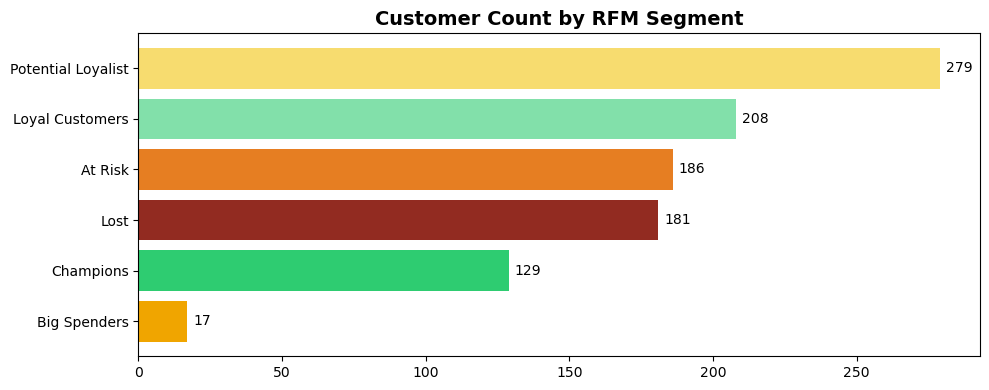

In [32]:
segment_counts = df_rfm['RFM_Label'].value_counts().sort_values(ascending=True)

color_map = {
    'Champions'          : '#2ecc71',   # rich green        
    'Loyal Customers'    : '#82e0aa',   # soft green        
    'Potential Loyalist' : '#f7dc6f',   # golden yellow     
    'Big Spenders'       : '#f0a500',   # amber             
    'At Risk'            : '#e67e22',   # burnt orange      
    'Lost'               : '#922b21',   # dark crimson      
}


colors = [color_map[label] for label in segment_counts.index]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(segment_counts.index, segment_counts.values, color=colors)  

for bar, val in zip(bars, segment_counts.values):                           
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', ha='left')

plt.title('Customer Count by RFM Segment',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Observations : 
- Here we can see that the business is highly dependend on Potential Loyalist and Hibernating customers, which is the area of focus. The priority should be bringing them closer to Loyal segment. 

### Segment wise Revenue : 

In [33]:
revenue = df_rfm.groupby('RFM_Label')['Monetary'].sum()    #calculating total revenue per segment
revenue = revenue.sort_values(ascending=True)
revenue = revenue.reset_index()
revenue.columns = ['RFM_Label', 'Total_Revenue']

revenue['Total_Revenue_K'] = (revenue['Total_Revenue'] / 1000).round(1)  #rounding of values in terms of Thousands 

In [34]:
revenue['Pct'] = (revenue['Total_Revenue'] / revenue['Total_Revenue'].sum() * 100).round(1)  # taking revenue as percentage


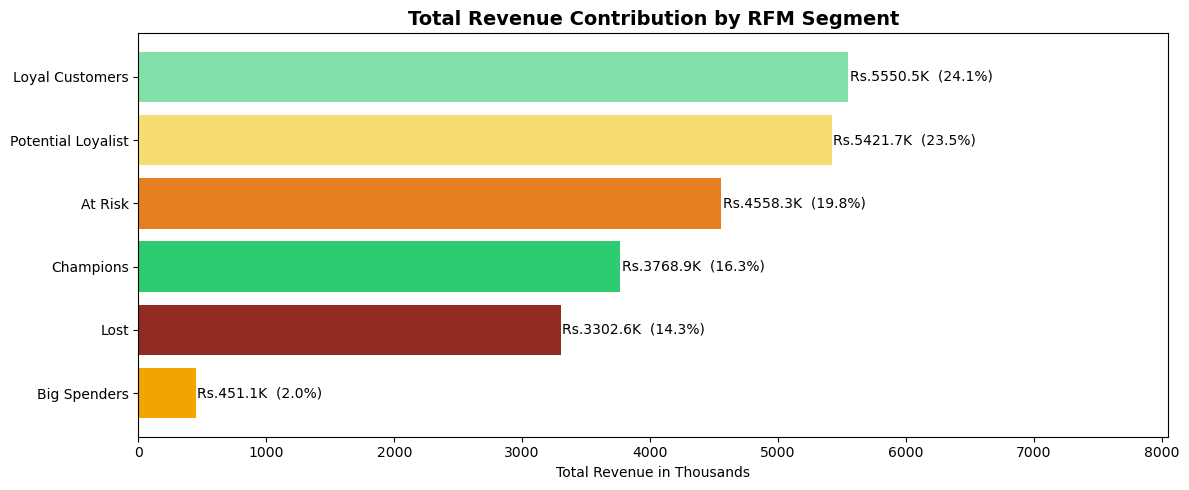

In [35]:
colors = [color_map[label] for label in revenue['RFM_Label']]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(revenue['RFM_Label'], revenue['Total_Revenue_K'], color=colors)
ax.set_xlim(0, revenue['Total_Revenue_K'].max() + 2500)


for i in range(len(bars)):
    bar = bars[i]
    rev = revenue['Total_Revenue_K'][i]
    pct = revenue['Pct'][i]
    ax.text(bar.get_width() + 10,
            bar.get_y() + bar.get_height() / 2,
            f'Rs.{rev}K  ({pct}%)',
            va='center', ha='left', fontsize=10)

ax.set_title('Total Revenue Contribution by RFM Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue in Thousands')

plt.tight_layout()
plt.show()

### Observations : 
- The revenue is highly  dependent on customers from Loyal and Potential Loyalist segment. we should focus to get the "Big Spenders" to the "Loyal" segments.

## Recency vs Monetary scatter plot colored segment-wise :

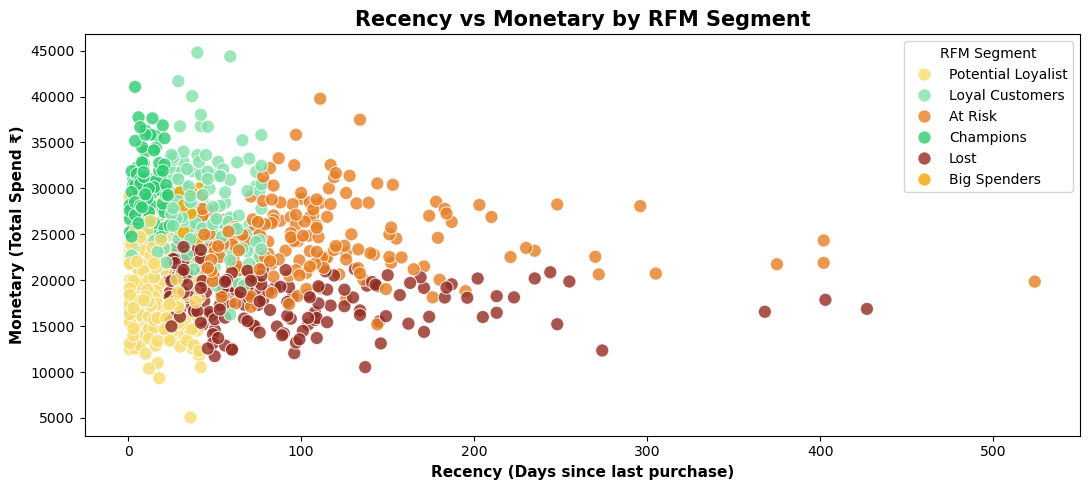

In [36]:

fig, ax = plt.subplots(figsize=(11
                                , 5))

sns.scatterplot(data    = df_rfm,
                x       = 'Recency',
                y       = 'Monetary',
                hue     = 'RFM_Label',
                palette = color_map,
                alpha   = 0.80,
                s       = 90,
                ax      = ax)

ax.set_title('Recency vs Monetary by RFM Segment', fontsize=15, fontweight='bold')
ax.set_xlabel('Recency (Days since last purchase)', fontsize=11,fontweight="bold")
ax.set_ylabel('Monetary (Total Spend ₹)', fontsize=11,fontweight="bold")

ax.legend(title='RFM Segment', bbox_to_anchor=(1.00, 1), loc='upper right')

plt.tight_layout()
plt.show()

### Observation :
- Customers who bought recently (low recency) tend to be in healthier segments like Loyal and , while customers who haven't bought in a long time (high recency) fall into at-risk & lost segments , we can say that recency is a strong indicator of customer health.

## Pareto Analysis : 

In [37]:
df_rfm = df_rfm.sort_values('Monetary', ascending=False).reset_index(drop=True)

total_revenue  = df_rfm['Monetary'].sum()
running_total = 0
customer_count = 0

for revenue in df_rfm['Monetary']:
    running_total  += revenue
    customer_count += 1
    if (running_total / total_revenue) * 100 >= 80:
        break

pct = round(customer_count / len(df_rfm) * 100, 2)
print(f'{pct}% of customers ({customer_count} out of {len(df_rfm)}) drive 80% of revenue')

72.0% of customers (720 out of 1000) drive 80% of revenue


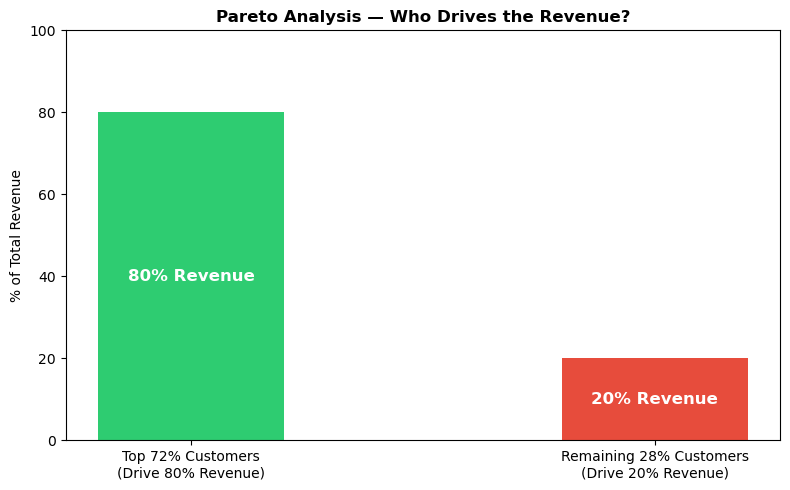

In [38]:
groups  = ['Top 72% Customers\n(Drive 80% Revenue)', 'Remaining 28% Customers\n(Drive 20% Revenue)']
heights = [80, 20]
colors  = ['#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 5))
bars    = ax.bar(groups, heights, color=colors, width=0.4)

for i in range(len(bars)):
    bar = bars[i]
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f'{heights[i]}% Revenue',
            ha='center', va='center',
            fontsize=12, fontweight='bold', color='white')

ax.set_title('Pareto Analysis — Who Drives the Revenue?',fontweight='bold')
ax.set_ylabel('% of Total Revenue')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

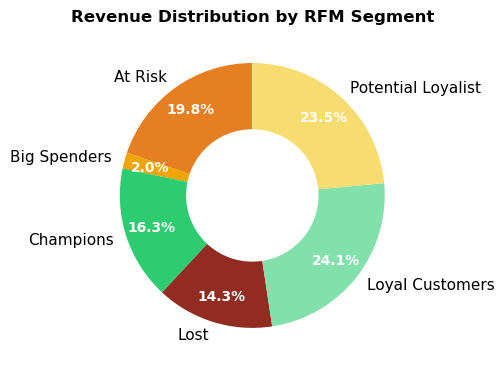

In [39]:

revenue = df_rfm.groupby('RFM_Label')['Monetary'].sum()

colors = [color_map[label] for label in revenue.index]

fig, ax = plt.subplots(figsize=(5, 5))

wedges, texts, autotexts = ax.pie(revenue,
                                   labels      = revenue.index,
                                   colors      = colors,
                                   autopct     = '%1.1f%%',
                                   pctdistance = 0.80,
                                   startangle  = 90,
                                   wedgeprops  = dict(width=0.5))

for text in texts:
    text.set_fontsize(11)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax.set_title('Revenue Distribution by RFM Segment',fontweight="bold")
plt.tight_layout()
plt.show()

### Observation :
- from the visual representation of the total revenue we can cleary understand that buisness is not quite dependent to a particular segment Loyal, Potential Loyalist drive most of the revenue.

## Inference :

1. Nearly 50% of revenue comes from Potential Loyalists and At Risk customers who are either uncommitted or going cold, a major business vulnerability.

2. Champions and Loyal Customers contribute only ~40% of revenue despite being the highest quality segment, stronger retention and upsell campaigns are needed.

3. It takes 72% of customers to drive 80% of revenue meaning the business lacks a strong high-value customer elite and needs to build one.

4.  Potential Loyalists (279 customers, 27% revenue) are the largest untapped group, converting them to Loyal with targeted campaigns is the highest ROI move.

5.  367 customers are Lost or At Risk representing over a third of the base, needs targeted apporach.